In [1]:
#ML (knn, rfc, svm, gridsearch, random search): Uyên

In [2]:
#KNN - Cat or dog

In [13]:
import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [4]:
def load_images(folder):
    data = []
    labels = []
    for label_name in ['cat', 'dog']:
        label = 0 if label_name == 'cat' else 1
        folder_path = os.path.join(folder, label_name)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.resize(img, (64, 64))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.flatten() / 255.0  
            data.append(img)
            labels.append(label)
    return np.array(data), np.array(labels)

In [5]:
print(os.getcwd())

C:\Users\thuuy\_python\ml


In [6]:
train_dir = r"C:\Users\thuuy\_python\ml\data_folder\train"
test_dir = r"C:\Users\thuuy\_python\ml\data_folder\test"
val_dir = r"C:\Users\thuuy\_python\ml\data_folder\val"


In [7]:
def count_images(folder):
    for label_name in ['cat', 'dog']:
        folder_path = os.path.join(folder, label_name)
        num_images = len(os.listdir(folder_path))
        print(f"{label_name.capitalize()} images in {folder}: {num_images}")

count_images(train_dir)
count_images(val_dir)
count_images(test_dir)

Cat images in C:\Users\thuuy\_python\ml\data_folder\train: 9985
Dog images in C:\Users\thuuy\_python\ml\data_folder\train: 10015
Cat images in C:\Users\thuuy\_python\ml\data_folder\val: 1248
Dog images in C:\Users\thuuy\_python\ml\data_folder\val: 1252
Cat images in C:\Users\thuuy\_python\ml\data_folder\test: 1268
Dog images in C:\Users\thuuy\_python\ml\data_folder\test: 1233


In [8]:
X_train, y_train = load_images(train_dir)
X_val, y_val     = load_images(val_dir)
X_test, y_test   = load_images(test_dir)

In [9]:
#random_k_list = random.sample(range(10, 120), 10) 
###Best k = 107, Validation Accuracy = 0.6108 Train Accuracy = 0.6396
#random_k_list = random.sample(range(90, 150), 5) 
###Best k = 146, Validation Accuracy = 0.6164 Train Accuracy = 0.6370 
#random_k_list = random.sample(range(1, 50), 5) 
###k =   7 Train Accuracy = 0.6883, Val Accuracy = 0.5924


In [10]:
# KNN
import random
random_k_list = random.sample(range(50, 120), 20)
best_k = None
best_val_acc = 0
for k in random_k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    print(f"k = {k} -> Validation Accuracy = {accuracy_score(y_val, y_val_pred)}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k

print(f"\n Best k = {best_k}, Validation Accuracy = {best_val_acc:.4f}")

k = 90 --> Validation Accuracy = 0.6088
k = 64 --> Validation Accuracy = 0.5972
k = 70 --> Validation Accuracy = 0.5996
k = 78 --> Validation Accuracy = 0.6084
k = 108 --> Validation Accuracy = 0.6092
k = 84 --> Validation Accuracy = 0.6080
k = 76 --> Validation Accuracy = 0.6056
k = 118 --> Validation Accuracy = 0.6096
k = 85 --> Validation Accuracy = 0.6088
k = 104 --> Validation Accuracy = 0.6084
k = 111 --> Validation Accuracy = 0.6112
k = 79 --> Validation Accuracy = 0.6092
k = 58 --> Validation Accuracy = 0.5996
k = 61 --> Validation Accuracy = 0.6012
k = 54 --> Validation Accuracy = 0.6048
k = 98 --> Validation Accuracy = 0.6068
k = 117 --> Validation Accuracy = 0.6144
k = 68 --> Validation Accuracy = 0.6024
k = 51 --> Validation Accuracy = 0.6036
k = 107 --> Validation Accuracy = 0.6108

 Best k = 117, Validation Accuracy = 0.6144


In [11]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_test_pred = knn_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy with best k={best_k}: {test_acc:.4f}")

Test Accuracy with best k=117: 0.6212



Classification Report on Test Set:

              precision    recall  f1-score   support

         Cat       0.61      0.69      0.65      1267
         Dog       0.63      0.55      0.59      1233

    accuracy                           0.62      2500
   macro avg       0.62      0.62      0.62      2500
weighted avg       0.62      0.62      0.62      2500

Confusion Matrix:
 [[878 389]
 [558 675]]
Confusion matrix saved to rfc_confusion_matrix.png


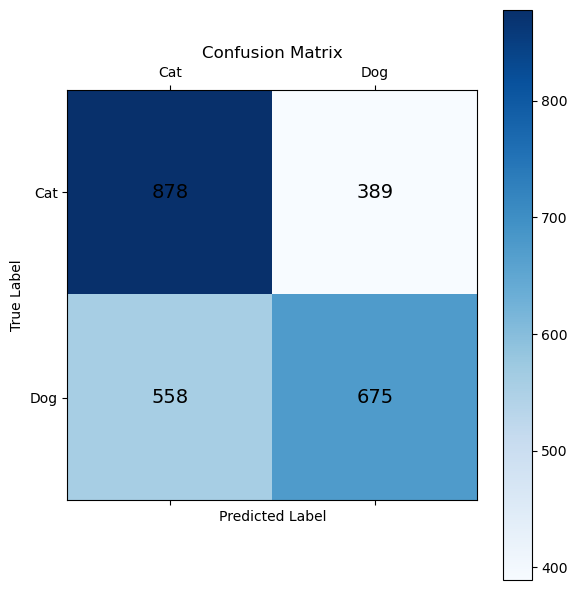

In [14]:
from sklearn.metrics import classification_report
print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, target_names=['Cat', 'Dog']))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

def plot_confusion_matrix(cm, class_names, save_path='rfc_confusion_matrix.png'):
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(cm, cmap='Blues')
    plt.colorbar(cax)
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)  
        print(f"Confusion matrix saved to {save_path}")
    plt.show()

plot_confusion_matrix(cm, ['Cat', 'Dog'])

